In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 800

categories = ['Technology', 'Furniture', 'Office Supplies', 'Clothing']
subcategories = {
    'Technology'      : ['Phones', 'Laptops', 'Accessories'],
    'Furniture'       : ['Chairs', 'Tables', 'Storage'],
    'Office Supplies' : ['Binders', 'Paper', 'Pens'],
    'Clothing'        : ['Shirts', 'Shoes', 'Accessories']
}
regions  = ['North', 'South', 'East', 'West']
segments = ['Consumer', 'Corporate', 'Home Office']
cities   = ['Bengaluru', 'Mumbai', 'Delhi', 'Chennai',
            'Hyderabad', 'Pune', 'Kolkata', 'Jaipur']

cat_list = np.random.choice(categories, n)
subcat_list = [np.random.choice(subcategories[c]) for c in cat_list]

df = pd.DataFrame({
    'Order_ID'    : [f'O{str(i).zfill(4)}' for i in range(1, n+1)],
    'Order_Date'  : pd.date_range('2023-01-01', periods=n, freq='10H'),
    'Customer_ID' : [f'C{np.random.randint(1,150):03d}' for _ in range(n)],
    'Segment'     : np.random.choice(segments, n),
    'City'        : np.random.choice(cities, n),
    'Region'      : np.random.choice(regions, n),
    'Category'    : cat_list,
    'Sub_Category': subcat_list,
    'Sales'       : np.round(np.random.exponential(600, n) + 100, 2),
    'Quantity'    : np.random.randint(1, 10, n),
    'Discount'    : np.round(np.random.choice([0,0.1,0.2,0.3,0.4], n), 1),
    'Profit'      : np.round(np.random.normal(90, 220, n), 2),
})

print(df.shape)
print(df.head())

(800, 12)
  Order_ID          Order_Date Customer_ID      Segment       City Region  \
0    O0001 2023-01-01 00:00:00        C053  Home Office     Jaipur  South   
1    O0002 2023-01-01 10:00:00        C099     Consumer  Hyderabad   West   
2    O0003 2023-01-01 20:00:00        C086     Consumer    Chennai  North   
3    O0004 2023-01-02 06:00:00        C108  Home Office     Jaipur  North   
4    O0005 2023-01-02 16:00:00        C024    Corporate     Mumbai   West   

          Category Sub_Category    Sales  Quantity  Discount  Profit  
0  Office Supplies      Binders   219.21         4       0.3   -1.22  
1         Clothing        Shoes   162.04         7       0.0  297.68  
2       Technology       Phones  1076.31         7       0.3  -11.72  
3  Office Supplies      Binders   178.09         1       0.0  180.52  
4  Office Supplies        Paper   180.20         6       0.1 -211.70  


/tmp/ipykernel_2981/2197838232.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'Order_Date'  : pd.date_range('2023-01-01', periods=n, freq='10H'),


In [ ]:
print("PROJECT TITLE: E-Commerce Sales & Customer Analysis")
print()
print("BUSINESS QUESTION:")
print("What drives revenue growth and which factors")
print("should the business focus on to improve profitability?")
print()
print("SUB-QUESTIONS:")
print("1. Which categories/products drive most revenue?")
print("2. Which regions are underperforming?")
print("3. What is the monthly sales trend?")
print("4. Does discount level hurt profitability?")
print("5. Which customer segment is most valuable?")
print()
print("ANALYSIS PLAN:")
print("Day 52: SQL queries + Pandas cleaning")
print("Day 53: Full EDA + 8 charts + stats")
print("Day 54: Tableau Dashboard 3")
print("Day 55: 5-Slide insight presentation")
print()
print("Project plan documented")

PROJECT TITLE: E-Commerce Sales & Customer Analysis

BUSINESS QUESTION:
What drives revenue growth and which factors
should the business focus on to improve profitability?

SUB-QUESTIONS:
1. Which categories/products drive most revenue?
2. Which regions are underperforming?
3. What is the monthly sales trend?
4. Does discount level hurt profitability?
5. Which customer segment is most valuable?

ANALYSIS PLAN:
Day 52: SQL queries + Pandas cleaning
Day 53: Full EDA + 8 charts + stats
Day 54: Tableau Dashboard 3
Day 55: 5-Slide insight presentation

Project plan documented


In [ ]:
# ══════════════════════════════════════
# QUICK EXPLORATION
# ══════════════════════════════════════

print("Date range:", df['Order_Date'].min().date(),
      "to", df['Order_Date'].max().date())
print("\nCategories:", df['Category'].unique().tolist())
print("\nRegions:", df['Region'].unique().tolist())
print("\nTotal unique customers:", df['Customer_ID'].nunique())
print("\nBasic stats:")
print(df[['Sales','Profit','Quantity','Discount']].describe().round(2))

Date range: 2023-01-01 to 2023-11-29

Categories: ['Office Supplies', 'Clothing', 'Technology', 'Furniture']

Regions: ['South', 'West', 'North', 'East']

Total unique customers: 147

Basic stats:
         Sales  Profit  Quantity  Discount
count   800.00  800.00    800.00    800.00
mean    711.27   82.73      5.09      0.19
std     565.43  213.36      2.50      0.14
min     101.21 -580.51      1.00      0.00
25%     301.25  -54.85      3.00      0.10
50%     545.73   87.04      5.00      0.20
75%     950.46  219.61      7.00      0.30
max    3475.81  698.55      9.00      0.40


In [ ]:
import sqlite3

# Create a database in memory and load your dataframe into it
conn = sqlite3.connect(':memory:')
df.to_sql('orders', conn, index=False, if_exists='replace')

print("Data loaded into SQL database ✅")
print(f"Total rows in SQL table: {pd.read_sql('SELECT COUNT(*) as cnt FROM orders', conn).iloc[0,0]}")

Data loaded into SQL database ✅
Total rows in SQL table: 800


In [ ]:
# Query 1: Total sales by category
query1 = """
SELECT
    Category,
    SUM(Sales) as Total_Sales,
    SUM(Profit) as Total_Profit,
    COUNT(*) as Order_Count
FROM orders
GROUP BY Category
ORDER BY Total_Sales DESC
"""

result1 = pd.read_sql(query1, conn)
print(result1)

          Category  Total_Sales  Total_Profit  Order_Count
0         Clothing    162627.01      25346.54          227
1       Technology    144017.94      14358.32          199
2        Furniture    133327.58      13951.34          187
3  Office Supplies    129041.92      12527.19          187


In [ ]:
# Query 2: Monthly sales trend
query2 = """
SELECT
    strftime('%Y-%m', Order_Date) as Month,
    SUM(Sales) as Total_Sales,
    COUNT(*) as Order_Count
FROM orders
GROUP BY Month
ORDER BY Month
"""

result2 = pd.read_sql(query2, conn)
print(result2)

      Month  Total_Sales  Order_Count
0   2023-01     46523.66           75
1   2023-02     49273.51           67
2   2023-03     52323.53           74
3   2023-04     48480.53           72
4   2023-05     56440.03           75
5   2023-06     47922.78           72
6   2023-07     56615.92           74
7   2023-08     50936.66           75
8   2023-09     56340.20           72
9   2023-10     57210.18           74
10  2023-11     46947.45           70


In [ ]:
# Query 3: Top 5 customers by spend
query3 = """
SELECT
    Customer_ID,
    SUM(Sales) as Total_Spend,
    COUNT(*) as Order_Count
FROM orders
GROUP BY Customer_ID
ORDER BY Total_Spend DESC
LIMIT 5
"""

result3 = pd.read_sql(query3, conn)
print(result3)

  Customer_ID  Total_Spend  Order_Count
0        C119      9194.91            9
1        C039      8433.04           11
2        C098      8269.21           10
3        C059      8228.35            8
4        C046      8195.09            9


In [ ]:
# ══════════════════════════════════════
# DATA CLEANING CHECK
# ══════════════════════════════════════

print("Checking for issues in the data:")
print()
print("Null values:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())
print()
print("Negative sales (shouldn't exist):", (df['Sales'] < 0).sum())
print("Negative quantity (shouldn't exist):", (df['Quantity'] < 0).sum())

Checking for issues in the data:

Null values:
Order_ID        0
Order_Date      0
Customer_ID     0
Segment         0
City            0
Region          0
Category        0
Sub_Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Duplicate rows: 0

Negative sales (shouldn't exist): 0
Negative quantity (shouldn't exist): 0


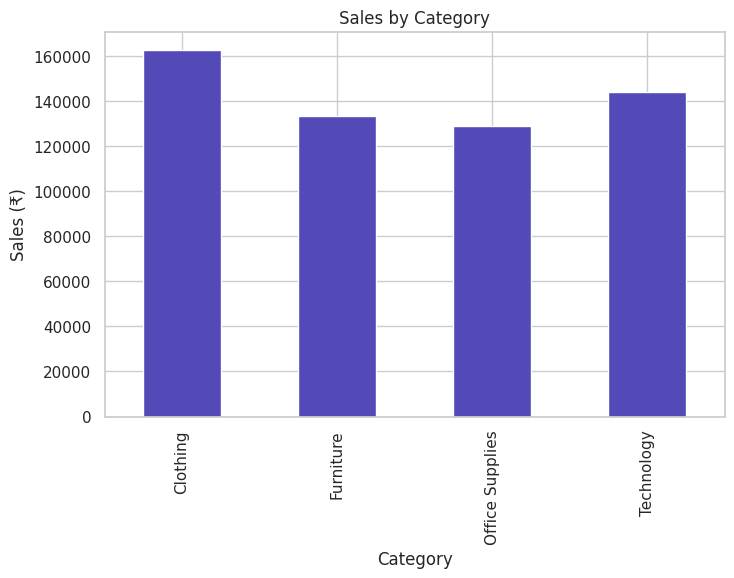

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color='#534AB7')
plt.title('Sales by Category')
plt.ylabel('Sales (₹)')
plt.show()

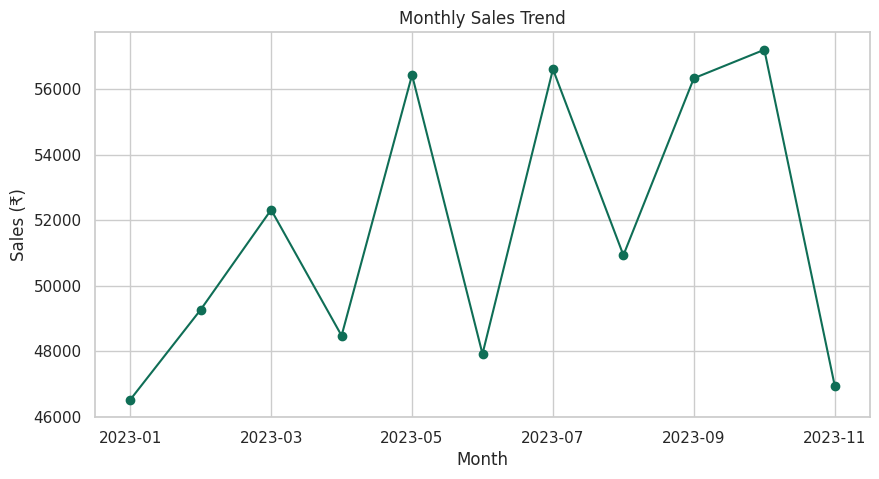

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o', color='#0F6E56')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales (₹)')
plt.show()

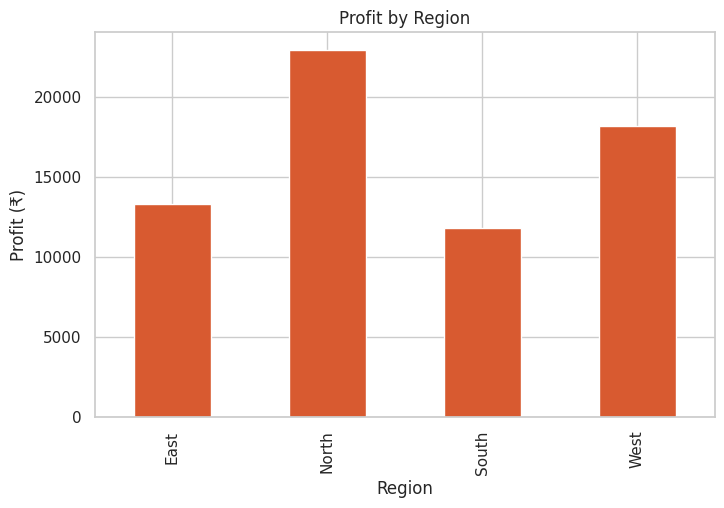

In [ ]:
region_profit = df.groupby('Region')['Profit'].sum()

plt.figure(figsize=(8,5))
region_profit.plot(kind='bar', color='#D85A30')
plt.title('Profit by Region')
plt.ylabel('Profit (₹)')
plt.show()

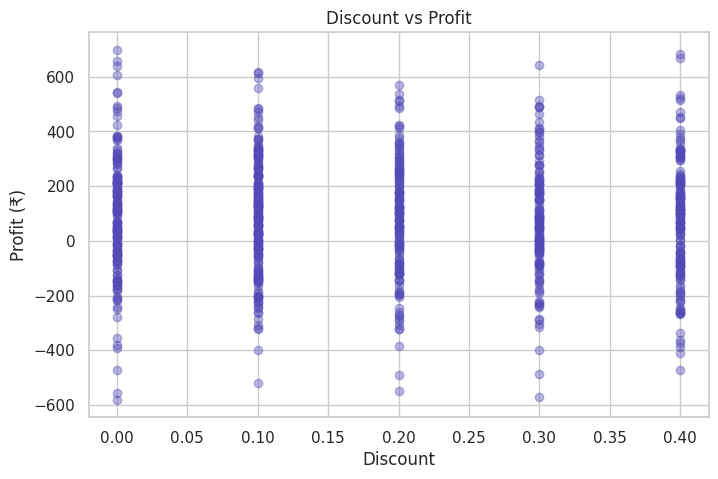

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.4, color='#534AB7')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit (₹)')
plt.show()

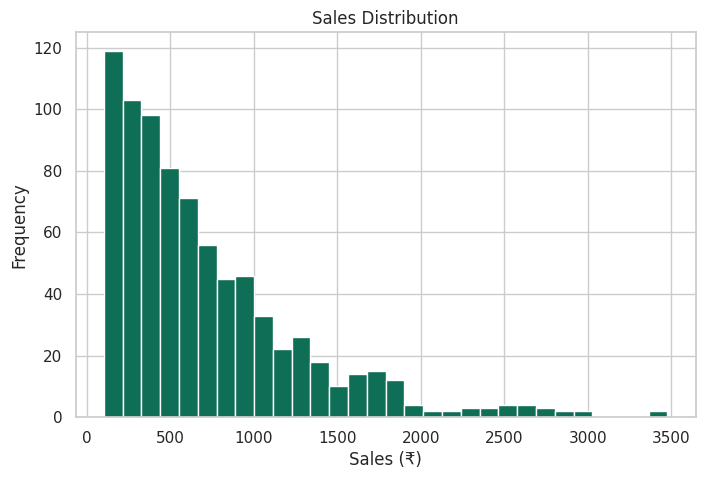

In [ ]:
plt.figure(figsize=(8,5))
df['Sales'].plot(kind='hist', bins=30, color='#0F6E56')
plt.title('Sales Distribution')
plt.xlabel('Sales (₹)')
plt.show()

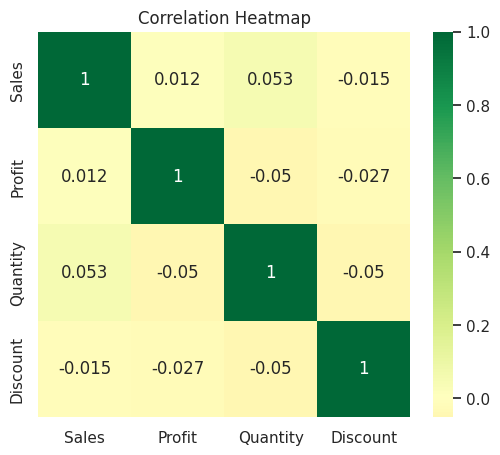

In [ ]:
plt.figure(figsize=(6,5))
corr = df[['Sales','Profit','Quantity','Discount']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.show()

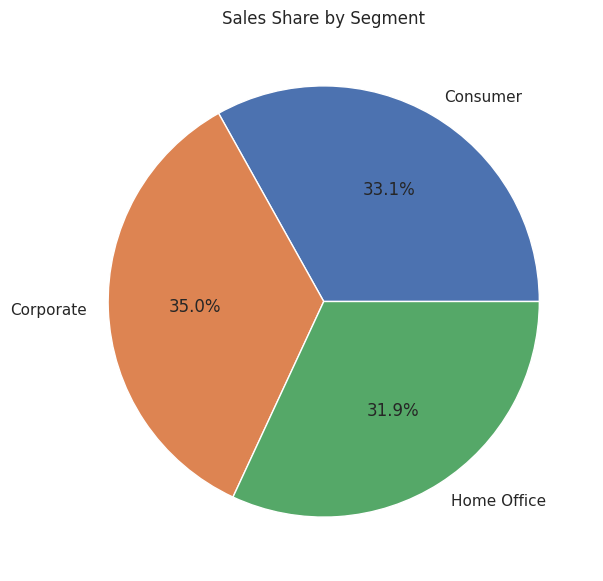

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(7,7))
segment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Share by Segment')
plt.ylabel('')
plt.show()

/tmp/ipykernel_2981/207085717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')


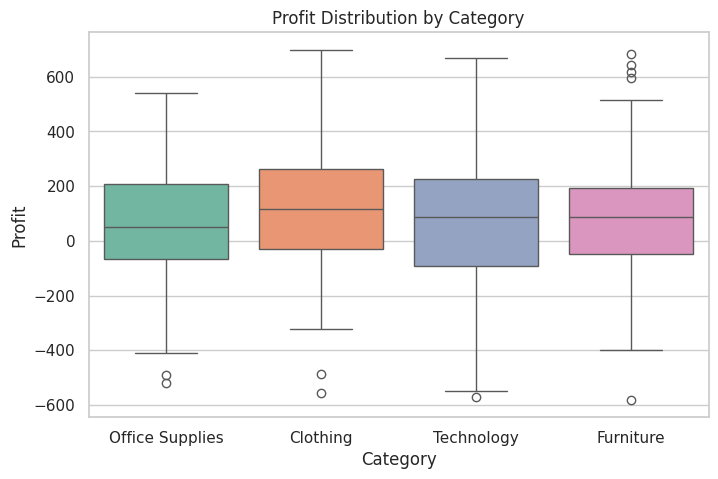

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')
plt.title('Profit Distribution by Category')
plt.show()

In [ ]:
# ══════════════════════════════════════
# BUSINESS INSIGHTS FROM CHARTS
# ══════════════════════════════════════

print("=" * 50)
print("   KEY INSIGHTS — PHASE 2 CAPSTONE")
print("=" * 50)

# Insight 1
best_cat = df.groupby('Category')['Sales'].sum().idxmax()
print(f"\n1. Top Category: {best_cat}")

# Insight 2
best_region = df.groupby('Region')['Profit'].sum().idxmax()
print(f"2. Most Profitable Region: {best_region}")

# Insight 3
discount_corr = df['Discount'].corr(df['Profit'])
print(f"3. Discount-Profit Correlation: {discount_corr:.2f}")

# Insight 4
loss_orders = (df['Profit'] < 0).sum()
loss_pct = round(loss_orders/len(df)*100, 1)
print(f"4. Loss-making orders: {loss_orders} ({loss_pct}%)")

# Insight 5
best_segment = df.groupby('Segment')['Sales'].sum().idxmax()
print(f"5. Top Segment: {best_segment}")

print("\n" + "=" * 50)

   KEY INSIGHTS — PHASE 2 CAPSTONE

1. Top Category: Clothing
2. Most Profitable Region: North
3. Discount-Profit Correlation: -0.03
4. Loss-making orders: 275 (34.4%)
5. Top Segment: Corporate



In [ ]:
df.to_csv("capstone_ecommerce_data.csv", index=False)

from google.colab import files
files.download("capstone_ecommerce_data.csv")

print("CSV exported and downloading...")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CSV exported and downloading...
